In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,precision_score, recall_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import seaborn as sns


%matplotlib inline


|Data columns|Purpose|Valid values|
| ------------- |:-------------| -----:|
age| Age of the patient |(in years)
sex|Sex of the patient |(1 = male, 0 = female)
cp| Chest pain type |(1-4)
trestbps|Resting blood pressure|(in mm Hg on admission to the hospital)
chol|Serum cholesterol|in mg/dl
fbs|Fasting blood sugar > 120 mg/dl |(1 = true; 0 = false)
restecg|Resting electrocardiographic results |0-2
thalach|Maximum heart rate achieved|
exang|Exercise-induced angina |1 = yes; 0 = no
oldpeak|ST depression induced by exercise relative to rest|
Target|0 = no heart disease, 1 = heart disease


In [2]:
#Reading the data file into the df variable
df = pd.read_csv("heart-disease.csv")

<h2>1. Evaluating & Cleaning The Data</h2>

In [3]:
#View the amount of rows and columns 
df.shape

(303, 14)

In [4]:
#Viewing the number of unique values in each column 
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [5]:
#Viewing how many of the values have null inputs
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
#View information about the dataframes contents
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
#View a few rows of data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
# Select the numeric columns to scale
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 1. Standardization (Z-score scaling)
scaler = StandardScaler() 
df_scaled = df.copy()  

# Apply scaling
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])


I used one-hot encoding on the categorical variables ('cp', 'restecg', 'thal'). These variables have multiple unordered categories, making the model interpret them as having a numeric relationship, which they do not. Encoding them transforms them into binary values, making it easier to evaluate them fairly.

In [9]:
# Perform one-hot encoding on categorical columns
df_encoded = pd.get_dummies(df_scaled, columns=['cp', 'restecg', 'thal'], drop_first=True, dtype= int)

In [10]:
# Check the data after encoding
df_encoded.head(10)

# Verify encoding was applied correctly

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,0.952197,1,0.763956,-0.256334,1,0.015443,0,1.087338,0,0,1,0,0,1,0,0,1,0,0
1,-1.915313,1,-0.092738,0.072199,0,1.633471,0,2.122573,0,0,1,0,1,0,1,0,0,1,0
2,-1.474158,0,-0.092738,-0.816773,0,0.977514,0,0.310912,2,0,1,1,0,0,0,0,0,1,0
3,0.180175,1,-0.663867,-0.198357,0,1.239897,0,-0.206705,2,0,1,1,0,0,1,0,0,1,0
4,0.290464,0,-0.663867,2.082050,0,0.583939,1,-0.379244,2,0,1,0,0,0,1,0,0,1,0
5,0.290464,1,0.478391,-1.048678,0,-0.072018,0,-0.551783,1,0,1,0,0,0,1,0,1,0,0
6,0.180175,0,0.478391,0.922521,0,0.146634,0,0.224643,1,0,1,1,0,0,0,0,0,1,0
7,-1.143291,1,-0.663867,0.323431,0,1.021244,0,-0.896862,2,0,1,1,0,0,1,0,0,0,1
8,-0.260980,1,2.306004,-0.913400,1,0.540209,0,-0.465514,2,0,1,0,1,0,1,0,0,0,1
9,0.290464,1,1.049520,-1.512490,0,1.064975,0,0.483451,2,0,1,0,1,0,1,0,0,1,0


<h2> 2. Splitting & Testing The Data</h2>

In [13]:
# Splitting the data in between test vs training data
X = df_encoded.drop(columns=['target'])  # Independent variables
y = df_encoded['target']  # Dependent variable (heart disease)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h2> 3. Create Model's and Test The Data </h2>

In [14]:
# Now the Fun part!
# Initialize the model
model = LogisticRegression()

# Train the model
results = model.fit(X_train, y_train)

# Make Predictions 
y_pred = model.predict(X_test)


In [17]:
# Initialize the model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
knn_pred = knn.predict(X_test)

<h2> 4. Evaluating The Model</h2>

In [23]:
# Calculate performance metrics for Logistic Regression Model
logr_accuracy = accuracy_score(y_test, y_pred)
logr_precision = precision_score(y_test, y_pred)
logr_recall = recall_score(y_test, y_pred)
logr_roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Logistic Regression Accuracy:", logr_accuracy)
print("Logistic Regression Precision:", logr_precision)
print("Logistic Regression Recall:", logr_recall)
print("Logistic Regression ROC-AUC Score:", logr_roc_auc)

# Calculate performance metrics for KNN Model
knn_accuracy = accuracy_score(y_test, knn_pred)  
knn_precision = precision_score(y_test, knn_pred)  
knn_recall = recall_score(y_test, knn_pred)
knn_roc_auc = roc_auc_score(y_test, knn.predict_proba(X_test)[:, 1])
print(f"--------------------------------------")
print("KNN Accuracy:", knn_accuracy)
print("KNN Precision:", knn_precision)
print("KNN Recall:", knn_recall)
print("KNN ROC-AUC Score:", knn_roc_auc)

Logistic Regression Accuracy: 0.9016393442622951
Logistic Regression Precision: 0.9333333333333333
Logistic Regression Recall: 0.875
Logistic Regression ROC-AUC Score: 0.9407327586206897
--------------------------------------
KNN Accuracy: 0.8524590163934426
KNN Precision: 0.8709677419354839
KNN Recall: 0.84375
KNN ROC-AUC Score: 0.9181034482758621


In [16]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Scores:", scores)
print(f"Mean CV Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation: {scores.std():.4f}")


Cross-Validation Scores: [0.80327869 0.90163934 0.78688525 0.83333333 0.73333333]
Mean CV Accuracy: 0.8117
Standard Deviation: 0.0555


I used 5-fold cross validation because it tests the accuracy of the model five times versus only testing 20% of random data. This lessens the likelihood of a lucky/unlucky split being chosen and evaluated on. The mean score provides a more reliable estimate of how well the model scored across all of the data.

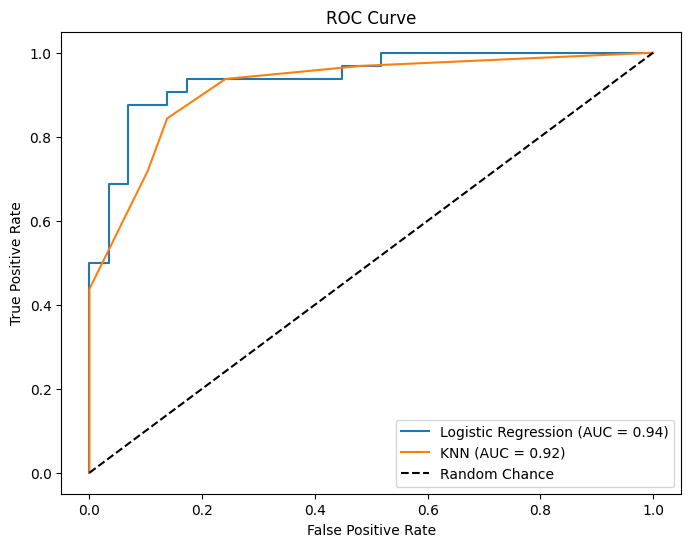

In [28]:
# Get the false positive rate, true positive rate, and thresholds
logr_fpr, logr_tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn.predict_proba(X_test)[:, 1])

# Plot
plt.figure(figsize=(8, 6))
plt.plot(logr_fpr, logr_tpr, label=f'Logistic Regression (AUC = {logr_roc_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



The ROC curve shows the tradeoff between catching real heart disease cases and creating false positives across all thresholds. The AUC summarizes the entire curve into one number -- The higher the number the better.

<h2>5. Interpreting The Model</h2>

The Logistic Regression outperformed the KNN model.

Accuracy: 0.9016 - 0.8524 = 0.05
Precision: 0.9333 - 0.8709 = 0.06
Recall: 0.875 - 0.844 = 0.03
ROC-AUC: 0.9407 - 0.9181 = 0.02
It is better suited for this type of data because the relationship between features like age, cholesterol, and blood pressure and heart disease risk follows predictable, linear patterns.

One limitation is that there were no values available for lifestyle factors for individuals. This would have provided a complete picture of the overall health of each individual making a more accurate prediction.

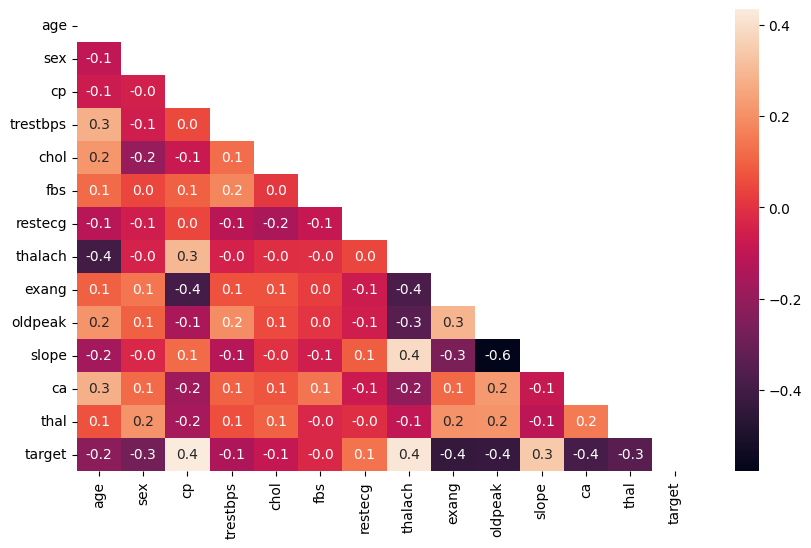

In [15]:
correlation_matrix = df.corr()
plt.figure(figsize=(10,6))
mask_ut = np.triu(np.ones(correlation_matrix.shape)).astype(np.bool_)
sns.heatmap(correlation_matrix, cmap='rocket',fmt=".1f", annot=True, mask=mask_ut)
plt.show()

In [27]:
coefficients = pd.DataFrame(model.coef_.flatten(), X.columns, columns=['Coefficient'])
print(coefficients)

           Coefficient
age          -0.023113
sex          -1.099996
trestbps     -0.248321
chol         -0.161500
fbs           0.366753
thalach       0.366840
exang        -0.966105
oldpeak      -0.587437
slope         0.574308
ca           -0.773215
cp_1          0.520033
cp_2          1.323581
cp_3          1.142124
restecg_1     0.470642
restecg_2    -0.011231
thal_1        0.204924
thal_2        0.522909
thal_3       -0.808062


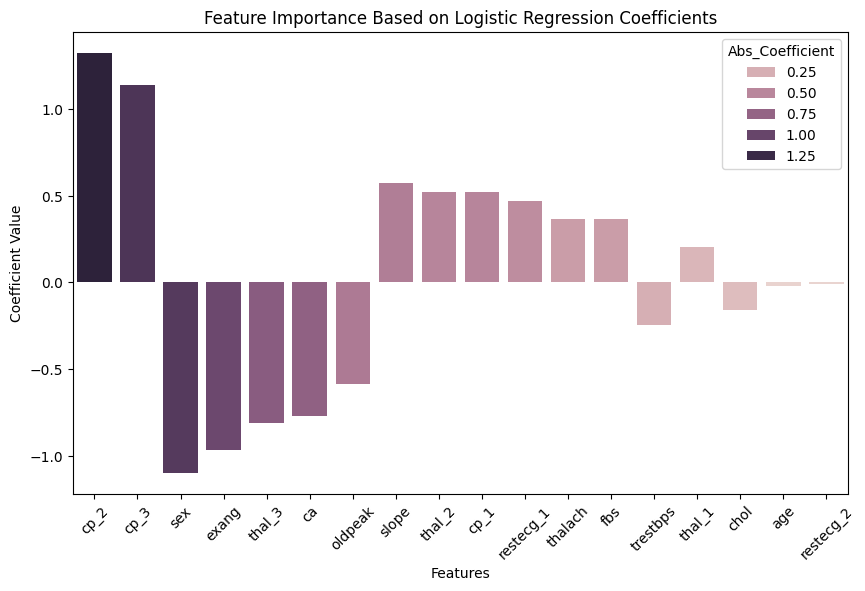

In [28]:
# Create a column for the absolute value of the coefficients
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()

# Sort the coefficients
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Create a bar plot of coefficients with a color map based on the strength of the relationship
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients.index, y='Coefficient', data=coefficients, hue='Abs_Coefficient')
plt.title('Feature Importance Based on Logistic Regression Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()
